In [89]:
                                       # Hourly Energy Consumption Forecast


import pandas as pd # it is used for handling dataset
import numpy as np # it is used for handling numerics
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/MyDrive/Datasets/PJMW_hourly.csv") # reads csv file
df # to display the dataframe

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0
...,...,...
143201,2018-01-01 20:00:00,8401.0
143202,2018-01-01 21:00:00,8373.0
143203,2018-01-01 22:00:00,8238.0
143204,2018-01-01 23:00:00,7958.0


In [90]:
df.shape[0] # shows the number of rows

143206

In [91]:
df.shape[1] # shows the number of rows and columns

2

In [92]:
df.shape

(143206, 2)

In [93]:
df.columns

Index(['Datetime', 'PJMW_MW'], dtype='object')

In [94]:
#Dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  143206 non-null  object 
 1   PJMW_MW   143206 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [95]:
df.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [96]:
df.tail()

,Datetime,PJMW_MW
143201,2018-01-01 20:00:00,8401.0
143202,2018-01-01 21:00:00,8373.0
143203,2018-01-01 22:00:00,8238.0
143204,2018-01-01 23:00:00,7958.0
143205,2018-01-02 00:00:00,7691.0


In [97]:
#Check missing values
df.isnull().sum()

,0
Datetime,0
PJMW_MW,0


In [98]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [99]:
# Convert Datetime column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])


In [100]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB


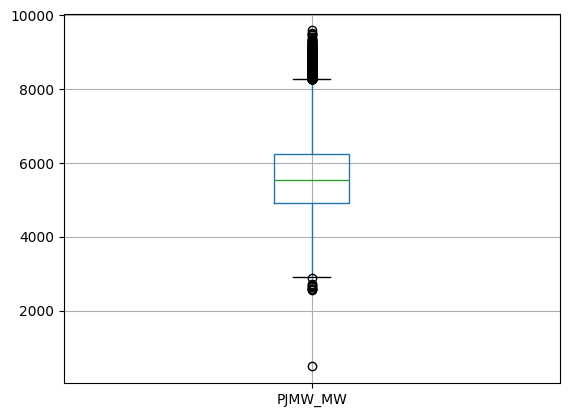

In [101]:
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

In [102]:
# Check date range
df['Datetime'].min(), df['Datetime'].max()

(Timestamp('2002-04-01 01:00:00'), Timestamp('2018-08-03 00:00:00'))

In [103]:
# Sort data by datetime
df = df.sort_values('Datetime')

In [104]:
# Calculate time difference between consecutive observations
df['Datetime'].diff().value_counts()

,count
Datetime,
0 days 01:00:00,143171
0 days 02:00:00,30
0 days 00:00:00,4


In [105]:
# Find gaps greater than 1 hour
df[df['Datetime'].diff() > pd.Timedelta(hours=1)]

,Datetime,PJMW_MW
6433,2002-04-07 04:00:00,4871.0
1561,2002-10-27 03:00:00,4014.0
13055,2003-04-06 04:00:00,4376.0
8183,2003-10-26 03:00:00,4027.0
21861,2004-04-04 04:00:00,4691.0
16821,2004-10-31 03:00:00,4006.0
30667,2005-04-03 04:00:00,5026.0
25627,2005-10-30 03:00:00,4673.0
39449,2006-04-02 04:00:00,3721.0
34409,2006-10-29 03:00:00,4367.0


In [106]:
# Check missing timestamps
full_range = pd.date_range(
    start=df['Datetime'].min(),
    end=df['Datetime'].max(),
    freq='h'
)

missing_timestamps = full_range.difference(df['Datetime'])
print(missing_timestamps)

DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00',
               '2011-11-06 02:00:00', '2012-03-11 03:00:00',
               '2012-11-04 02:00:00', '2013-03-10 03:00:00',
               '2013-11-03 02:00:00', '2014-03-09 03:00:00',
               '2015-03-08 03:00:00', '2016-03-13 03:00:00',
               '2017-03-12 03:00:00', '2018-03-11 03:00:00'],
              dtype='datetime64[ns]', freq=None)


In [107]:
# checking th length of the timestamps
len(missing_timestamps)

30

In [108]:
# Check the data around the unusual timestamp
df[
    (df['Datetime'] >= '2010-12-09 22:00:00') &
    (df['Datetime'] <= '2010-12-10 03:00:00')
]

,Datetime,PJMW_MW
68501,2010-12-09 22:00:00,7354.0
68502,2010-12-09 23:00:00,6972.0
68456,2010-12-10 01:00:00,6280.0
68457,2010-12-10 02:00:00,6117.0
68458,2010-12-10 03:00:00,6035.0


In [109]:
# Get statistical summary of energy consumption
df['PJMW_MW'].describe()

,PJMW_MW
count,143206.000000
mean,5602.375089
std,979.142872
min,487.000000
25%,4907.000000
50%,5530.000000
75%,6252.000000
max,9594.000000


In [110]:
# Check dates of highest energy consumption values
df.nlargest(10, 'PJMW_MW')

,Datetime,PJMW_MW
119310,2015-02-20 08:00:00,9594.0
119346,2015-02-19 20:00:00,9536.0
119309,2015-02-20 07:00:00,9512.0
119345,2015-02-19 19:00:00,9489.0
119311,2015-02-20 09:00:00,9481.0
119347,2015-02-19 21:00:00,9424.0
119214,2015-02-24 08:00:00,9366.0
111618,2014-01-07 20:00:00,9349.0
143105,2018-01-05 20:00:00,9342.0
143104,2018-01-05 19:00:00,9325.0


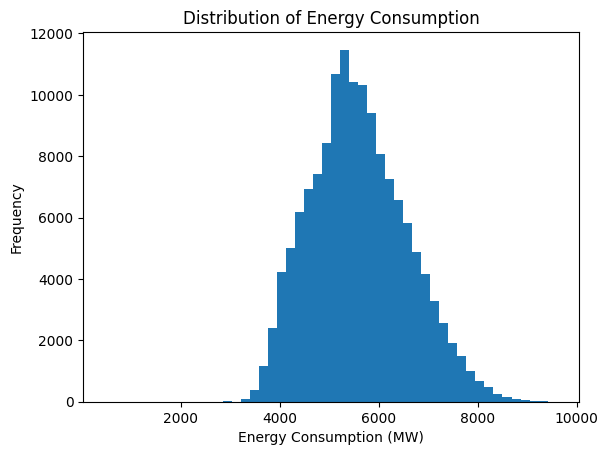

In [111]:
# plotting the graph using a histogram to visualize the distribution of energy consumption."
plt.hist(df['PJMW_MW'], bins=50)
plt.xlabel('Energy Consumption (MW)')
plt.ylabel('Frequency')
plt.title('Distribution of Energy Consumption')
plt.show()
# Most consumption values are concentrated around 5,000–6,000 MW

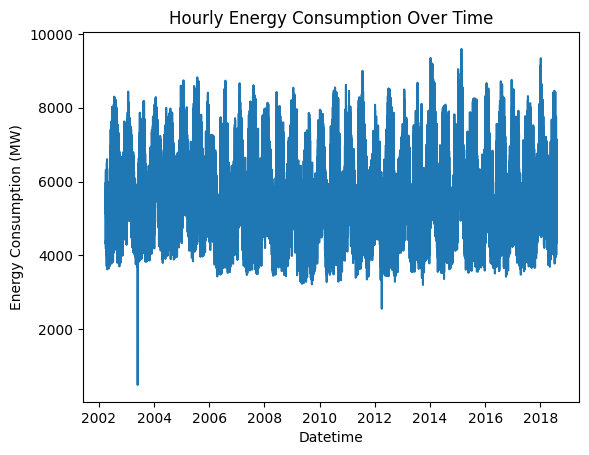

In [112]:
# plotting the graph to visualize the energy consumption over time.
plt.plot(df['Datetime'], df['PJMW_MW'])
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.title('Hourly Energy Consumption Over Time')
plt.show()
#We can observe frequent fluctuations, with several peaks and drops across the years.”

In [113]:
# Extract hour from Datetime
df['Hour'] = df['Datetime'].dt.hour

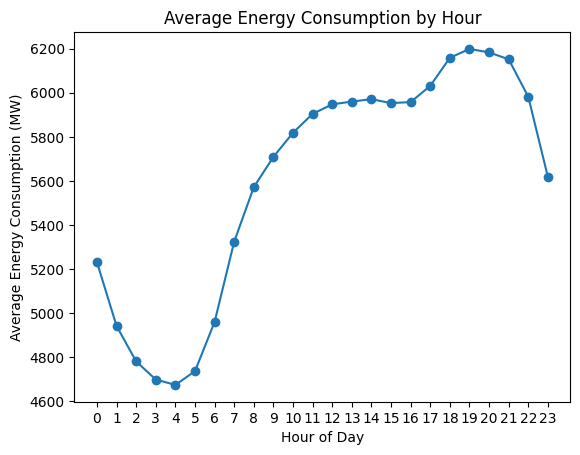

In [114]:
# "Plotting the graph to visualize the energy consumption by hour."
hourly_avg = df.groupby('Hour')['PJMW_MW'].mean()

plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Hour')
plt.xticks(range(24))
plt.show()
# It shows that consumption decreases from 00:00 to around 04:00,
# then increases from 05:00 to 19:00, reaching the highest level around 19:00. After 19:00, it gradually decreases and drops sharply by 23:00.

In [115]:
# Extract day of week
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

In [116]:
# Average consumption by day of week
df.groupby('DayOfWeek')['PJMW_MW'].mean()


,PJMW_MW
DayOfWeek,
0,5700.518783
1,5801.076837
2,5802.370701
3,5780.841051
4,5686.839202
5,5293.999413
6,5149.638300


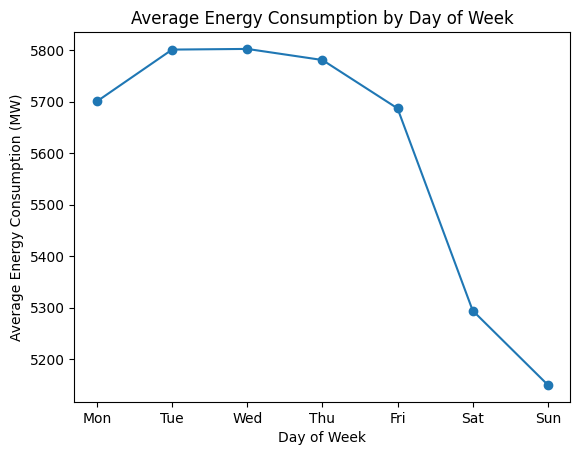

In [117]:
#"Plotting the average energy consumption to visualize the energy consumption by day of the week.
daily_avg = df.groupby('DayOfWeek')['PJMW_MW'].mean()

plt.plot(daily_avg.index, daily_avg.values, marker='o')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Day of Week')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()
# This graph shows that energy consumption increases from Monday to Tuesday, stays almost stable on Wednesday
# then gradually decreases through Friday. It drops significantly on Saturday and reaches the lowest level on Sunday.

In [118]:
# Extract month from Datetime
df['Month'] = df['Datetime'].dt.month

In [119]:
# Average consumption by month
monthly_avg = df.groupby('Month')['PJMW_MW'].mean()
monthly_avg

,PJMW_MW
Month,
1,6447.667759
2,6296.808813
3,5654.097376
4,5022.310855
5,5015.845746
6,5516.756046
7,5861.537081
8,5822.142809
9,5205.872049


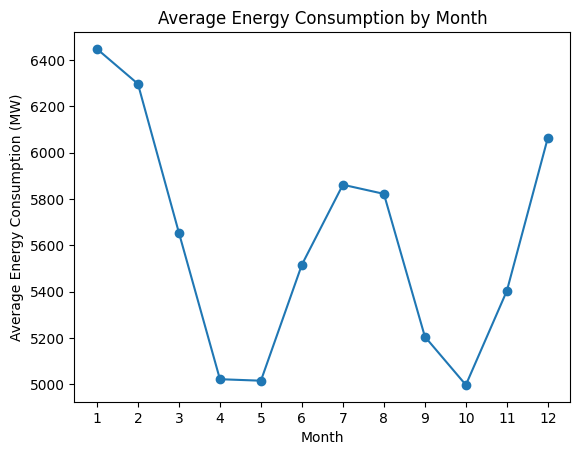

In [120]:
# This graph shows the average energy consumption by month
plt.plot(monthly_avg.index, monthly_avg.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Average Energy Consumption by Month')
plt.xticks(range(1, 13))
plt.show()
# Energy is highest in January and December, lower around April and October, and rises again in summer and winter months.

In [121]:
# This code identifies which dates in our dataset are holidays and calculates the average energy consumption for holidays versus non-holidays.
from pandas.tseries.holiday import USFederalHolidayCalendar

cal = USFederalHolidayCalendar()

holidays = cal.holidays(
    start=df["Datetime"].min(),
    end=df["Datetime"].max()
)

df["Holiday"] = df["Datetime"].dt.normalize().isin(holidays)

holiday_avg = df.groupby("Holiday")["PJMW_MW"].mean()

holiday_avg

,PJMW_MW
Holiday,
False,5604.746436
True,5517.403035


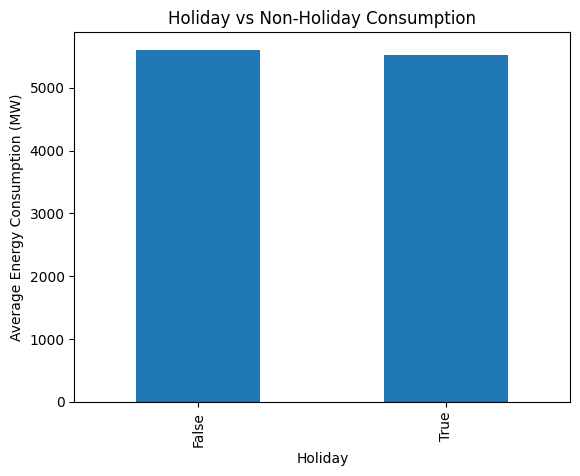

In [122]:
#plotting the graph to compare energy consumption between holidays and non-holiday

holiday_avg.plot(kind="bar")
plt.xlabel("Holiday")
plt.ylabel("Average Energy Consumption (MW)")
plt.title("Holiday vs Non-Holiday Consumption")
plt.show()
# It shows that holidays have slightly lower average energy consumption than non-holidays.

In [123]:
# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

In [124]:
# Average consumption by season
season_avg=df.groupby('Season')['PJMW_MW'].mean()

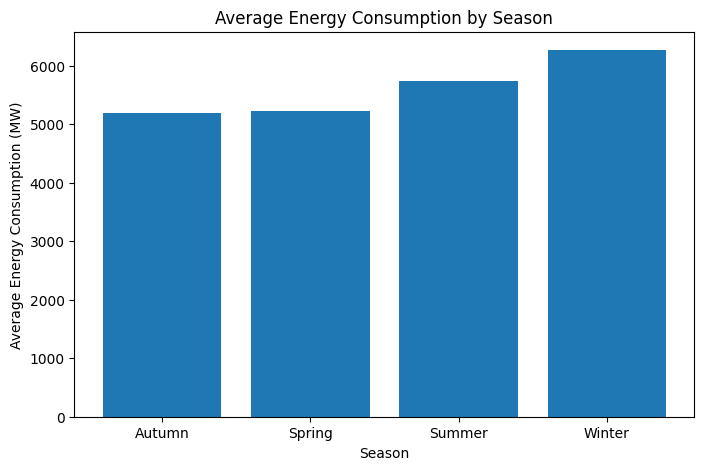

In [125]:

plt.figure(figsize=(8,5))

plt.bar(season_avg.index, season_avg.values)

plt.title('Average Energy Consumption by Season')
plt.xlabel('Season')
plt.ylabel('Average Energy Consumption (MW)')

plt.show()
# This bar graph shows average energy consumption by season. Winter has the highest energy use, and autumn and spring have the lowest.

In [126]:
# Create weekend feature
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6])

In [127]:
# Compare weekday and weekend consumption
weekend_avg=df.groupby('IsWeekend')['PJMW_MW'].mean()

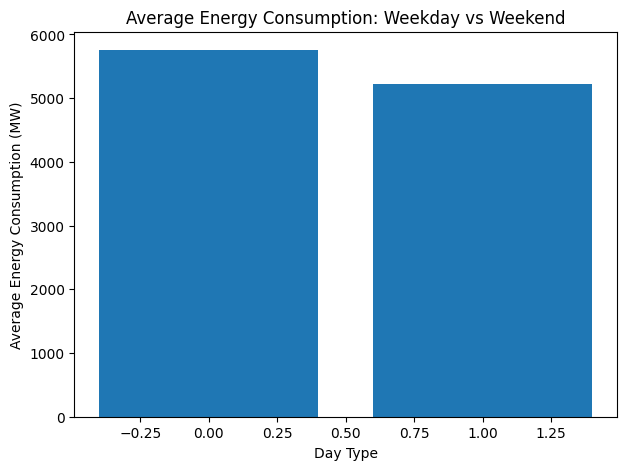

In [128]:
plt.figure(figsize=(7,5))

plt.bar(weekend_avg.index, weekend_avg.values)

plt.title('Average Energy Consumption: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Energy Consumption (MW)')

plt.show()
# This graph compares average energy use on weekdays versus weekends. Weekdays have higher energy use than weekends.

In [129]:
# Extract date
df['Date'] = df['Datetime'].dt.date

# Daily average consumption
daily_avg = df.groupby('Date')['PJMW_MW'].mean()

daily_avg.head()

,PJMW_MW
Date,
2002-04-01,5271.173913
2002-04-02,5310.416667
2002-04-03,5325.916667
2002-04-04,5670.791667
2002-04-05,5686.125000


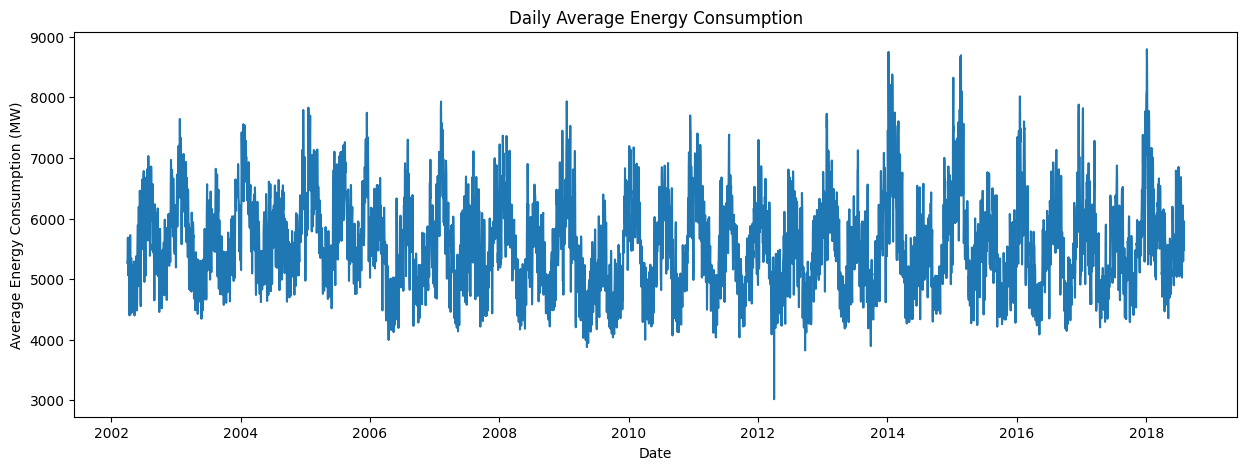

In [130]:
# Plot daily average consumption
plt.figure(figsize=(15, 5))
plt.plot(daily_avg.index, daily_avg.values)
plt.xlabel('Date')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Daily Average Energy Consumption')
plt.show()
# The energy is highest around 2003 to 2005 and near 2014. It’s lowest around 2007 and 2012."

In [131]:
# Extract week from Datetime
df['Week'] = df['Datetime'].dt.isocalendar().week

In [132]:
# Average consumption by week
weekly_avg = df.groupby('Week')['PJMW_MW'].mean()
weekly_avg

,PJMW_MW
Week,
1,6257.026414
2,6318.961682
3,6531.527530
4,6591.927827
5,6443.927083
6,6489.469866
7,6272.683780
8,6156.854167
9,6136.135789


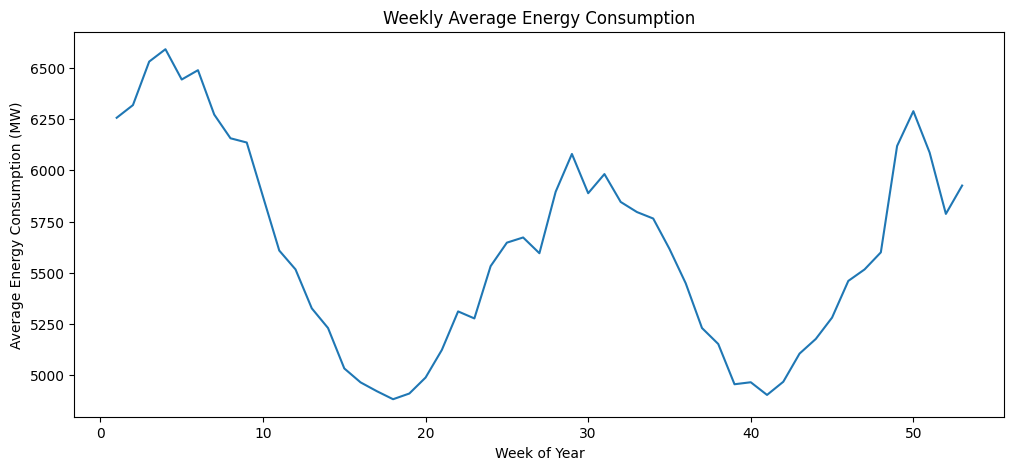

In [133]:
# Plot weekly average consumption
plt.figure(figsize=(12, 5))
plt.plot(weekly_avg.index, weekly_avg.values)
plt.xlabel('Week of Year')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('Weekly Average Energy Consumption')
plt.show()
# The energy consumption is high around the start of the year and near the end of the year.
# It’s lowest around the middle of the year, roughly between weeks 20 to 30.

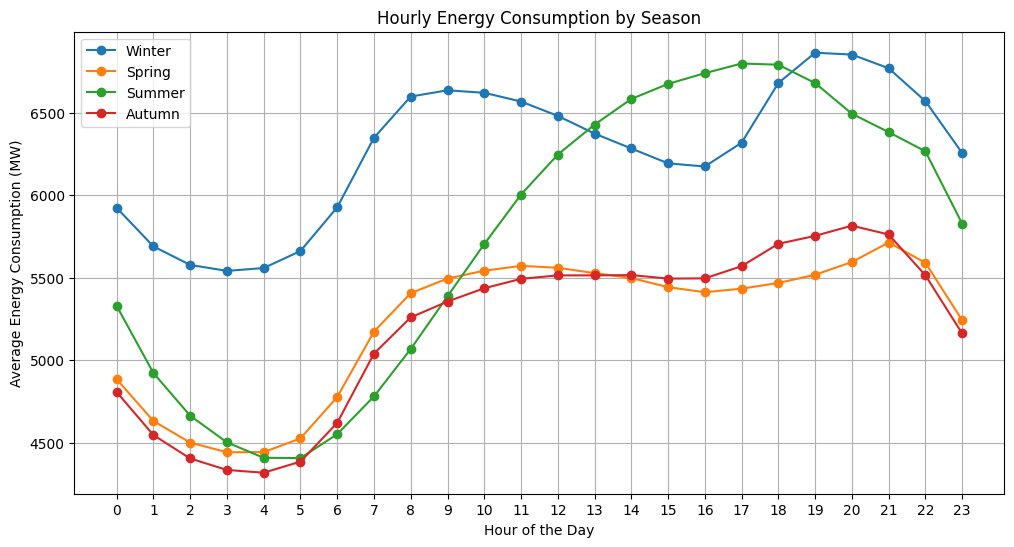

In [134]:
# this code calculates the average energy use for each hour of the day in each season.
hour_season = df.groupby(
    ['Season', 'Hour']
)['PJMW_MW'].mean().unstack(level=0)

plt.figure(figsize=(12,6))

plt.plot(hour_season.index, hour_season['Winter'], marker='o', label='Winter')
plt.plot(hour_season.index, hour_season['Spring'], marker='o', label='Spring')
plt.plot(hour_season.index, hour_season['Summer'], marker='o', label='Summer')
plt.plot(hour_season.index, hour_season['Autumn'], marker='o', label='Autumn')

plt.title('Hourly Energy Consumption by Season')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Energy Consumption (MW)')

plt.xticks(range(24))
plt.legend()
plt.grid()

plt.show()
# This graph shows how energy use changes during the day for each season.
# The lines show winter, spring, summer, and autumn. Winter and summer evenings use more energy, while early mornings are lower.

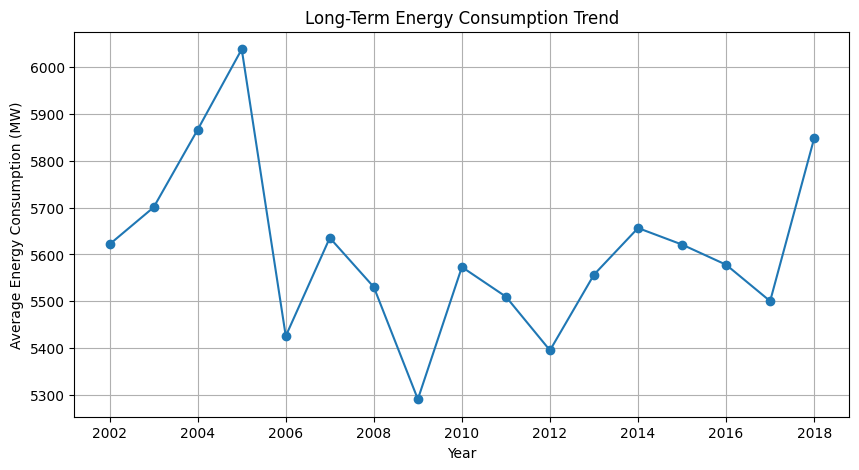

In [135]:
# Extract Year from Datetime
df['Year'] = df['Datetime'].dt.year
# Calculate average energy consumption by Year
year_avg = df.groupby('Year')['PJMW_MW'].mean()

# Plot Long-Term Energy Consumption Trend
plt.figure(figsize=(10, 5))

plt.plot(year_avg.index, year_avg.values, marker='o')

plt.title('Long-Term Energy Consumption Trend')
plt.xlabel('Year')
plt.ylabel('Average Energy Consumption (MW)')

plt.grid()
plt.show()
# "This graph shows how average energy consumption changed each year.
# It had ups and downs, with a high point around 2005, a drop after that, and another rise near 2018."

In [136]:
# Previous hour consumption
df['lag_1'] = df['PJMW_MW'].shift(1)

In [137]:
# Previous day same-hour consumption
df['lag_24'] = df['PJMW_MW'].shift(24)

In [138]:
# Previous week same-hour consumption
df['lag_168'] = df['PJMW_MW'].shift(168)

In [139]:
# Check autocorrelation
df['PJMW_MW'].autocorr()
# it checks if the current value is correlated with previous values.

np.float64(0.9746791642158641)

In [140]:
# it shows data is stationary or not
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
result = adfuller(df['PJMW_MW'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -19.88829608963819
p-value: 0.0


/tmp/ipykernel_3736/4029194918.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df['PJMW_MW'])


In [141]:
# Create time-based features

df['Hour'] = df['Datetime'].dt.hour
df['DayOfWeek'] = df['Datetime'].dt.dayofweek
df['Month'] = df['Datetime'].dt.month

In [142]:
# Correlation of features with target

correlation = df[['Hour', 'DayOfWeek', 'Month', 'PJMW_MW']].corr()

print(correlation['PJMW_MW'].sort_values(ascending=False))

PJMW_MW      1.000000
Hour         0.447239
Month       -0.152412
DayOfWeek   -0.202858
Name: PJMW_MW, dtype: float64


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143206 entries, 6574 to 138094
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Datetime   143206 non-null  datetime64[ns]
 1   PJMW_MW    143206 non-null  float64       
 2   Hour       143206 non-null  int32         
 3   DayOfWeek  143206 non-null  int32         
 4   Month      143206 non-null  int32         
 5   Holiday    143206 non-null  bool          
 6   Season     143206 non-null  object        
 7   IsWeekend  143206 non-null  bool          
 8   Date       143206 non-null  object        
 9   Week       143206 non-null  UInt32        
 10  Year       143206 non-null  int32         
 11  lag_1      143205 non-null  float64       
 12  lag_24     143182 non-null  float64       
 13  lag_168    143038 non-null  float64       
dtypes: UInt32(1), bool(2), datetime64[ns](1), float64(4), int32(4), object(2)
memory usage: 11.9+ MB


In [144]:
# Select input features and target

X = df[['Hour', 'DayOfWeek', 'Month']]   # Input features
y = df['PJMW_MW']                        # Target value

In [145]:
# Split data based on year

train_data = df[df['Datetime'].dt.year < 2018].copy()   # Before 2018 → Training
test_data = df[df['Datetime'].dt.year == 2018].copy()   # 2018 → Testing

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (138070, 14)
Testing data: (5136, 14)


In [146]:
# Create training and testing features

features = ['Hour', 'DayOfWeek', 'Month']

X_train = train_data[features].copy()   # Training input features
y_train = train_data['PJMW_MW'].copy()  # Training target

X_test = test_data[features].copy()     # Testing input features
y_test = test_data['PJMW_MW'].copy()   # Testing target

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (138070, 3)
y_train: (138070,)
X_test: (5136, 3)
y_test: (5136,)


In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

# Create 6 regression models

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}

print("6 models created successfully")

6 models created successfully


In [148]:
# Train all 6 models

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained successfully")

Linear Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully
XGBoost trained successfully
Gradient Boosting trained successfully
KNN trained successfully


In [149]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)   # Predict testing data

print("Predictions created successfully")

Predictions created successfully


In [150]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate all 6 models

for name, pred in predictions.items():

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    print("\n", name)
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)


 Linear Regression
MAE: 700.9774702059434
MSE: 826509.1831082368
RMSE: 909.1255045967177
R2: 0.199304494417316

 Decision Tree
MAE: 590.7166511597267
MSE: 585665.3059610379
RMSE: 765.2877275646316
R2: 0.4326262940053748

 Random Forest
MAE: 510.86505124518914
MSE: 469611.5907509899
RMSE: 685.2821249317611
R2: 0.5450553995422327

 XGBoost
MAE: 511.00671814535264
MSE: 469800.25175168563
RMSE: 685.4197631755927
R2: 0.544872630834488

 Gradient Boosting
MAE: 530.586580855507
MSE: 497802.406569819
RMSE: 705.5511367504265
R2: 0.5177450441509488

 KNN
MAE: 534.7504283489097
MSE: 497876.3903037383
RMSE: 705.603564548634
R2: 0.5176733710897825


In [151]:
results = {
    "Linear Regression": [
        mean_absolute_error(y_test, predictions["Linear Regression"]),
        mean_squared_error(y_test, predictions["Linear Regression"]),
        np.sqrt(mean_squared_error(y_test, predictions["Linear Regression"])),
        r2_score(y_test, predictions["Linear Regression"])
    ],

    "Decision Tree": [
        mean_absolute_error(y_test, predictions["Decision Tree"]),
        mean_squared_error(y_test, predictions["Decision Tree"]),
        np.sqrt(mean_squared_error(y_test, predictions["Decision Tree"])),
        r2_score(y_test, predictions["Decision Tree"])
    ],

    "Random Forest": [
        mean_absolute_error(y_test, predictions["Random Forest"]),
        mean_squared_error(y_test, predictions["Random Forest"]),
        np.sqrt(mean_squared_error(y_test, predictions["Random Forest"])),
        r2_score(y_test, predictions["Random Forest"])
    ],

    "XGBoost": [
        mean_absolute_error(y_test, predictions["XGBoost"]),
        mean_squared_error(y_test, predictions["XGBoost"]),
        np.sqrt(mean_squared_error(y_test, predictions["XGBoost"])),
        r2_score(y_test, predictions["XGBoost"])
    ],

    "Gradient Boosting": [
        mean_absolute_error(y_test, predictions["Gradient Boosting"]),
        mean_squared_error(y_test, predictions["Gradient Boosting"]),
        np.sqrt(mean_squared_error(y_test, predictions["Gradient Boosting"])),
        r2_score(y_test, predictions["Gradient Boosting"])
    ],

    "KNN": [
        mean_absolute_error(y_test, predictions["KNN"]),
        mean_squared_error(y_test, predictions["KNN"]),
        np.sqrt(mean_squared_error(y_test, predictions["KNN"])),
        r2_score(y_test, predictions["KNN"])
    ]
}

results_df = pd.DataFrame(
    results,
    index=["MAE", "MSE", "RMSE", "R2"]
).T

results_df

,MAE,MSE,RMSE,R2
Linear Regression,700.977470,826509.183108,909.125505,0.199304
Decision Tree,590.716651,585665.305961,765.287728,0.432626
Random Forest,510.865051,469611.590751,685.282125,0.545055
XGBoost,511.006718,469800.251752,685.419763,0.544873
Gradient Boosting,530.586581,497802.406570,705.551137,0.517745
KNN,534.750428,497876.390304,705.603565,0.517673


In [152]:
from statsmodels.tsa.arima.model import ARIMA

# Create ARIMA training series using data before 2018
arima_train = train_data.set_index('Datetime')['PJMW_MW'].copy()
arima_test = test_data.set_index('Datetime')['PJMW_MW']
# Remove duplicate timestamps
arima_train = arima_train[~arima_train.index.duplicated(keep='first')]

# Set hourly frequency
arima_train = arima_train.asfreq('h')

# Fill missing hourly values using time interpolation
arima_train = arima_train.interpolate(method='time')

# Create ARIMA model
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1)
)

# Train ARIMA
arima_result = arima_model.fit()

print("ARIMA model trained successfully")

ARIMA model trained successfully


In [153]:
# Predict 2018 test period
arima_pred = arima_result.forecast(
    steps=len(arima_test)
)

print("ARIMA predictions created successfully")
print(arima_pred.head())

ARIMA predictions created successfully
2018-01-01 00:00:00    7603.469420
2018-01-01 01:00:00    7532.407677
2018-01-01 02:00:00    7485.005594
2018-01-01 03:00:00    7453.385803
2018-01-01 04:00:00    7432.293667
Freq: h, Name: predicted_mean, dtype: float64


In [154]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluate ARIMA model

arima_mae = mean_absolute_error(arima_test, arima_pred)
arima_mse = mean_squared_error(arima_test, arima_pred)
arima_rmse = np.sqrt(arima_mse)
arima_r2 = r2_score(arima_test, arima_pred)

print("ARIMA")
print("MAE :", arima_mae)
print("MSE :", arima_mse)
print("RMSE:", arima_rmse)
print("R2  :", arima_r2)

ARIMA
MAE : 1636.4228284644148
MSE : 3409613.559318703
RMSE: 1846.5138936164826
R2  : -2.3031239198739115


In [155]:
results_df.loc["ARIMA"] = [
    arima_mae,
    arima_mse,
    arima_rmse,
    arima_r2
]

results_df

,MAE,MSE,RMSE,R2
Linear Regression,700.977470,8.265092e+05,909.125505,0.199304
Decision Tree,590.716651,5.856653e+05,765.287728,0.432626
Random Forest,510.865051,4.696116e+05,685.282125,0.545055
XGBoost,511.006718,4.698003e+05,685.419763,0.544873
Gradient Boosting,530.586581,4.978024e+05,705.551137,0.517745
KNN,534.750428,4.978764e+05,705.603565,0.517673
ARIMA,1636.422828,3.409614e+06,1846.513894,-2.303124


In [156]:
# SARIMA Training data — before 2018
train_sarima = train_data.set_index('Datetime')['PJMW_MW'].copy()

# SARIMA Testing data — 2018
test_sarima = test_data.set_index('Datetime')['PJMW_MW'].copy()

print("SARIMA Training:", train_sarima.shape)
print("SARIMA Testing :", test_sarima.shape)

SARIMA Training: (138070,)
SARIMA Testing : (5136,)


In [157]:
# Remove duplicate timestamps
train_sarima = train_sarima[~train_sarima.index.duplicated(keep='first')]  # Duplicate timestamps remove

# Set hourly frequency
train_sarima = train_sarima.asfreq('h')                                    # Every 1 hour

# Fill missing hourly values
train_sarima = train_sarima.interpolate(method='time')                     # Time-based interpolation

print("Missing values:", train_sarima.isna().sum())
print("Training shape:", train_sarima.shape)

Missing values: 0
Training shape: (138095,)


In [158]:
# Use last 90 days of training data
sarima_train_fast = train_sarima.tail(90 * 24).copy()   # 90 days × 24 hours

print("SARIMA training data:", sarima_train_fast.shape)
print("SARIMA test data:", test_sarima.shape)

SARIMA training data: (2160,)
SARIMA test data: (5136,)


In [159]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    sarima_train_fast,
    order=(1, 0, 1),                  # Non-seasonal part
    seasonal_order=(1, 0, 1, 24),     # Daily seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    disp=False,
    maxiter=50                         # Limit iterations for faster training
)

print("SARIMA model trained successfully")

SARIMA model trained successfully


In [160]:
# Predict 2018 energy consumption
sarima_pred = sarima_result.forecast(
    steps=len(test_sarima)              # Number of 2018 test observations
)

print("SARIMA predictions created successfully")
print(sarima_pred.head())

SARIMA predictions created successfully
2018-01-01 00:00:00    7463.257816
2018-01-01 01:00:00    7255.776553
2018-01-01 02:00:00    7133.181619
2018-01-01 03:00:00    7086.640491
2018-01-01 04:00:00    7099.887310
Freq: h, Name: predicted_mean, dtype: float64


In [161]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

sarima_mae = mean_absolute_error(test_sarima, sarima_pred)       # MAE
sarima_mse = mean_squared_error(test_sarima, sarima_pred)        # MSE
sarima_rmse = np.sqrt(sarima_mse)                                # RMSE
sarima_r2 = r2_score(test_sarima, sarima_pred)                    # R²

print("SARIMA")
print("MAE :", sarima_mae)
print("MSE :", sarima_mse)
print("RMSE:", sarima_rmse)
print("R2  :", sarima_r2)

SARIMA
MAE : 1811.2875356693412
MSE : 4928437.49270685
RMSE: 2220.008444287285
R2  : -3.7745116819092734


In [162]:
# Add SARIMA results to the comparison table
results_df.loc["SARIMA"] = [
    sarima_mae,          # MAE
    sarima_mse,          # MSE
    sarima_rmse,         # RMSE
    sarima_r2            # R2
]

results_df

,MAE,MSE,RMSE,R2
Linear Regression,700.977470,8.265092e+05,909.125505,0.199304
Decision Tree,590.716651,5.856653e+05,765.287728,0.432626
Random Forest,510.865051,4.696116e+05,685.282125,0.545055
XGBoost,511.006718,4.698003e+05,685.419763,0.544873
Gradient Boosting,530.586581,4.978024e+05,705.551137,0.517745
KNN,534.750428,4.978764e+05,705.603565,0.517673
ARIMA,1636.422828,3.409614e+06,1846.513894,-2.303124
SARIMA,1811.287536,4.928437e+06,2220.008444,-3.774512


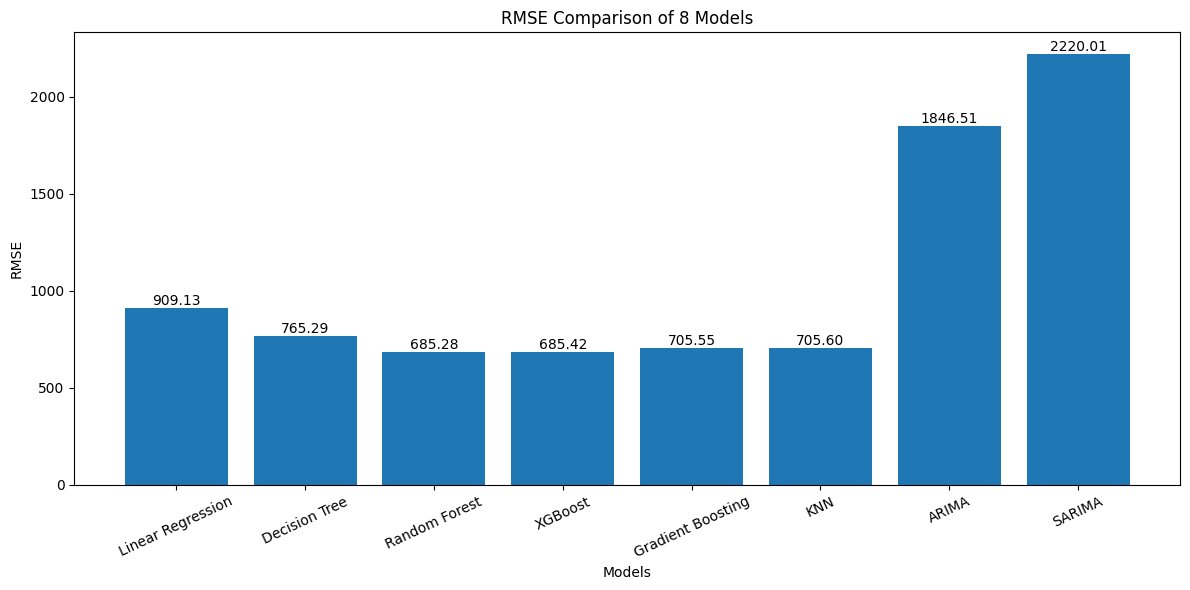

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

bars = plt.bar(
    results_df.index,
    results_df['RMSE']
)

plt.title("RMSE Comparison of 8 Models")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=25)

# Show RMSE value on each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [164]:
# Best model based on RMSE
best_model = results_df['RMSE'].idxmin()       # Lowest RMSE model name
best_rmse = results_df['RMSE'].min()           # Lowest RMSE value
best_r2 = results_df.loc[best_model, 'R2']     # R2 of best model

print("Best Model:", best_model)
print("Best RMSE:", best_rmse)
print("Best R2:", best_r2)

Best Model: Random Forest
Best RMSE: 685.2821249317611
Best R2: 0.5450553995422327


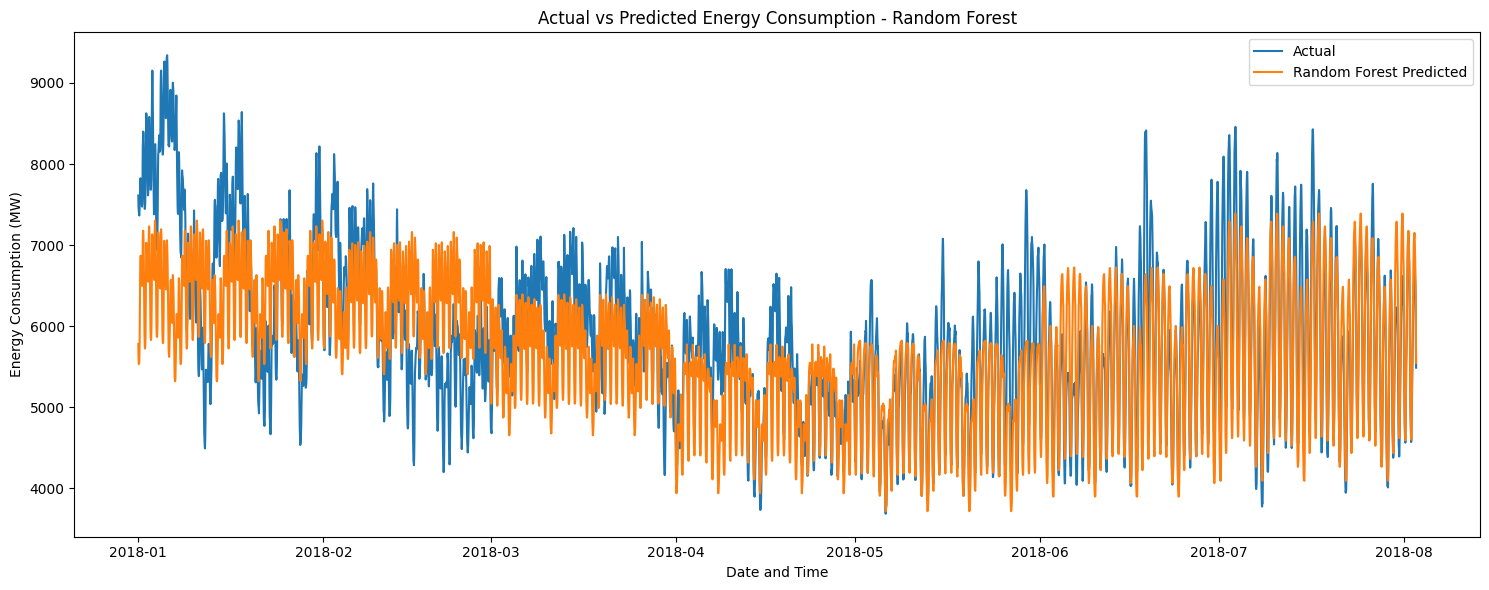

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    test_data['Datetime'],
    y_test.values,
    label='Actual'
)

plt.plot(
    test_data['Datetime'],
    predictions['Random Forest'],
    label='Random Forest Predicted'
)

plt.title('Actual vs Predicted Energy Consumption - Random Forest')
plt.xlabel('Date and Time')
plt.ylabel('Energy Consumption (MW)')
plt.legend()

plt.tight_layout()
plt.show()

In [166]:
#Training features
features = [
    'Hour',
    'DayOfWeek',
    'Month',
    'Holiday',
    'IsWeekend',
    'Week',
    'Year',
    'lag_1',
    'lag_24',
    'lag_168'
]

In [167]:
X_full = df[features]
y_full = df['PJMW_MW']

In [168]:
#Building the Random Forest Model
final_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

final_rf.fit(X_full, y_full)

RandomForestRegressor(random_state=42)

In [169]:
# Get the last date and time available in the dataset
last_datetime = df['Datetime'].max()

# Create the next 720 hourly timestamps for forecasting
future_dates = pd.date_range(
    start=last_datetime + pd.Timedelta(hours=1),# Start from the next hour
    periods=720,                                  # Generate 720 future hours
    freq='h'                                      # Frequency is 1 hour
)

# Display the first and last future date and time
print(future_dates.min())
print(future_dates.max())
print("Number of future hours:", len(future_dates))

2018-08-03 01:00:00
2018-09-02 00:00:00
Number of future hours: 720


In [170]:
import numpy as np
import pandas as pd

# Historical values for creating lag features
history = list(df['PJMW_MW'].values)

future_predictions = []

last_datetime = df['Datetime'].max()

future_dates = pd.date_range(
    start=last_datetime + pd.Timedelta(hours=1),
    periods=720,
    freq='h'
)

for current_date in future_dates:

    # Calendar features
    hour = current_date.hour
    day_of_week = current_date.dayofweek
    month = current_date.month
    is_weekend = int(day_of_week >= 5)
    week = current_date.isocalendar().week
    year = current_date.year

    # Season
    if month in [12, 1, 2]:
        season = 'Winter'
    elif month in [3, 4, 5]:
        season = 'Spring'
    elif month in [6, 7, 8]:
        season = 'Summer'
    else:
        season = 'Autumn'

    # Season encoding
    season_spring = int(season == 'Spring')
    season_summer = int(season == 'Summer')
    season_winter = int(season == 'Winter')

    # Holiday
    is_holiday = int(
        current_date.normalize()
        in holidays
    )

    # Lag features
    lag_1 = history[-1]
    lag_24 = history[-24]
    lag_168 = history[-168]


    # Create feature row
    future_features = pd.DataFrame([{
        'Hour': hour,
        'DayOfWeek': day_of_week,
        'Month': month,
        'Holiday': is_holiday,
        'IsWeekend': is_weekend,
        'Week': week,
        'Year': year,
        'lag_1': lag_1,
        'lag_24': lag_24,
        'lag_168': lag_168
    }])

    # Prediction
    prediction = final_rf.predict(future_features)[0]

    # Save prediction
    future_predictions.append(prediction)

    # Add prediction to history
    # so it can be used for future lags
    history.append(prediction)

In [171]:
forecast_df = pd.DataFrame({
    'Datetime': future_dates,
    'Predicted_PJMW_MW': future_predictions
})

print(forecast_df)

               Datetime  Predicted_PJMW_MW
0   2018-08-03 01:00:00            5067.40
1   2018-08-03 02:00:00            4792.89
2   2018-08-03 03:00:00            4628.75
3   2018-08-03 04:00:00            4534.92
4   2018-08-03 05:00:00            4549.24
..                  ...                ...
715 2018-09-01 20:00:00            6289.51
716 2018-09-01 21:00:00            6205.72
717 2018-09-01 22:00:00            5902.74
718 2018-09-01 23:00:00            5476.07
719 2018-09-02 00:00:00            5022.44

[720 rows x 2 columns]


30-Day Forecast of Hourly Energy Consumption

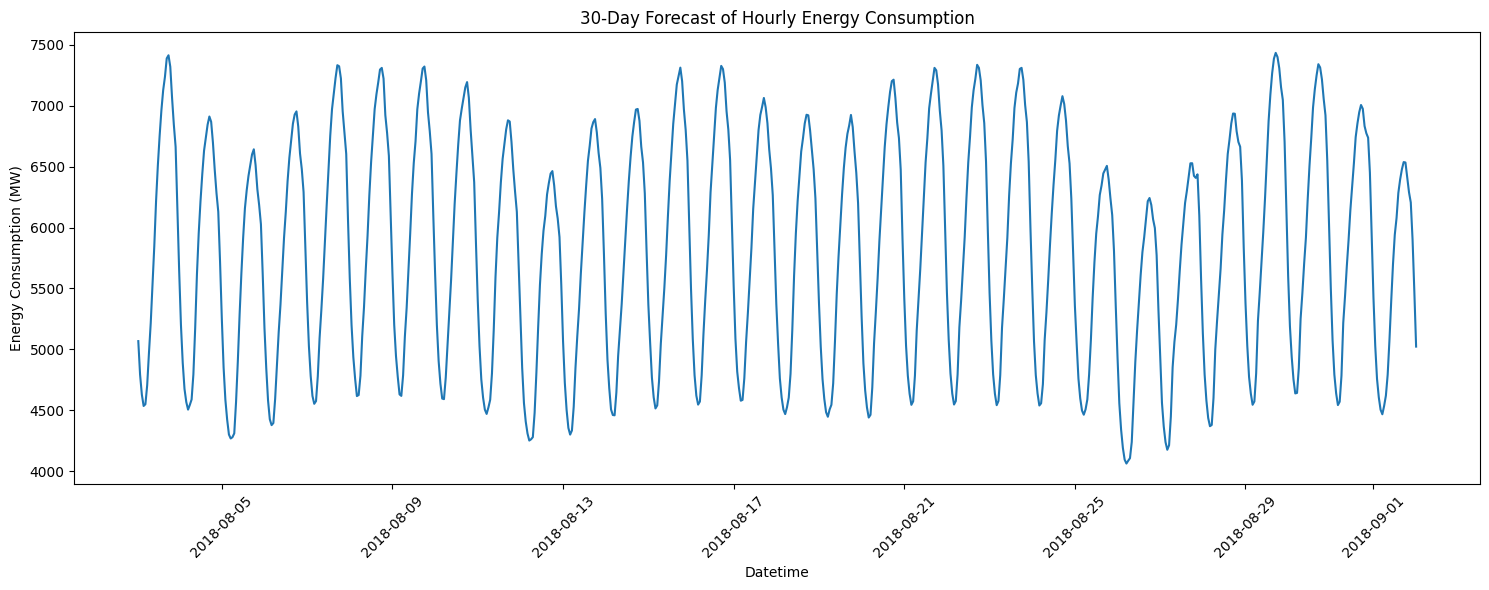

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    forecast_df['Datetime'],
    forecast_df['Predicted_PJMW_MW']
)

plt.xlabel('Datetime')
plt.ylabel('Energy Consumption (MW)')
plt.title('30-Day Forecast of Hourly Energy Consumption')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average, minimum and maximum consumption in days

In [177]:
forecast_summary = forecast_df.copy()

forecast_summary['Forecast_Day'] = (
    np.arange(len(forecast_summary)) // 24
) + 1

In [174]:
daily_forecast = forecast_summary.groupby('Forecast_Day').agg(
    Average_Consumption=('Predicted_PJMW_MW', 'mean'),
    Minimum_Consumption=('Predicted_PJMW_MW', 'min'),
    Maximum_Consumption=('Predicted_PJMW_MW', 'max')
)

In [175]:
print(daily_forecast)

              Average_Consumption  Minimum_Consumption  Maximum_Consumption
Forecast_Day                                                               
1                     6048.107083              4534.92              7414.07
2                     5737.611250              4505.11              6911.35
3                     5490.663750              4268.01              6642.17
4                     5753.919583              4377.65              6953.37
5                     6032.149583              4552.74              7332.50
6                     6066.936250              4616.35              7310.49
7                     6069.684167              4617.87              7321.70
8                     5968.212500              4590.99              7193.97
9                     5698.699167              4469.74              6880.00
10                    5392.420833              4251.18              6463.22
11                    5707.286667              4300.00              6890.37
12          

30-Day Average Energy Consumption Forecast

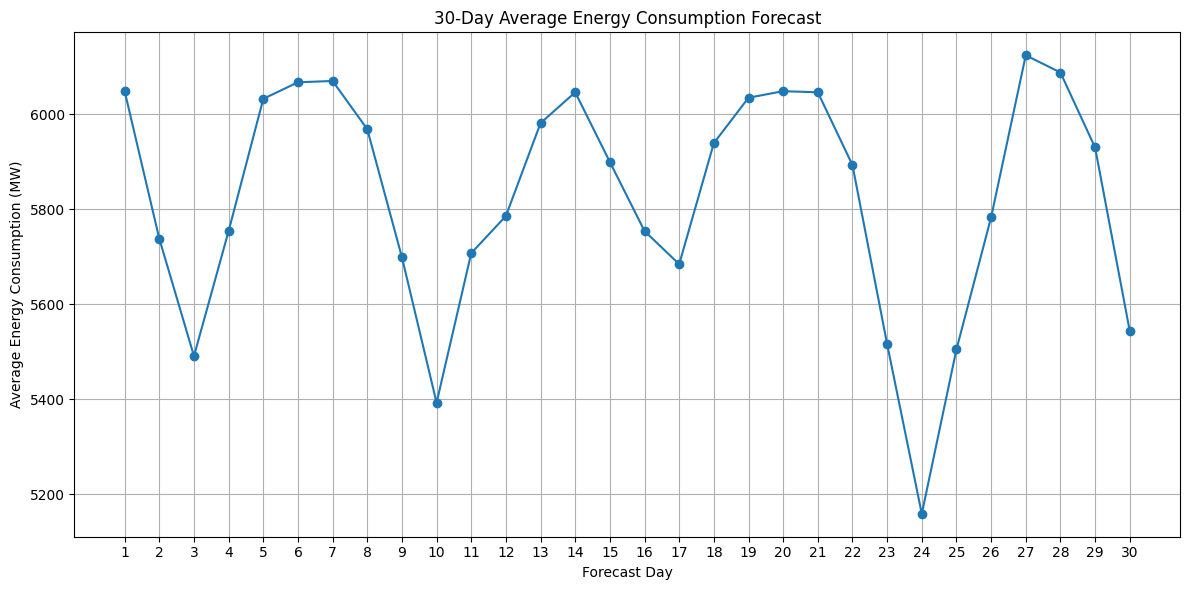

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    daily_forecast.index,
    daily_forecast['Average_Consumption'],
    marker='o'
)

plt.xlabel('Forecast Day')
plt.ylabel('Average Energy Consumption (MW)')
plt.title('30-Day Average Energy Consumption Forecast')

plt.xticks(range(1, 31))
plt.grid(True)
plt.tight_layout()
plt.show()

Deployment with Streamlit

In [179]:
from pickle import dump

dump(final_rf, open('random_forest_model.pkl', 'wb'))

In [180]:
from pickle import load

model = load(open('random_forest_model.pkl', 'rb'))

In [181]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'random_forest_model.pkl', 'sample_data']
